In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import *
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from PycalcAct.calculateCustomAccuracy import calculateCustomAccuracy
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)



In [2]:

# dataFolder = Path(//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/dataset_mcgill")
# dataFolder = Path("D:/Ca2-Analysis_McGill/prediction/agAffinity/dataset_mcgill")
dataFolder = Path("D:/Sebastien/Ca2-Analysis_McGill/prediction/agAffinity/datasets/dataset_mcgill")


csv_path=[dataFolder.joinpath("legend.csv"), dataFolder.joinpath("calciumRatio_normalized.csv")] 
csv_pos_path = dataFolder.joinpath("position.csv")


In [3]:

dataset = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path, 
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    forEval = False,
    customFilter = False,
    is_regression = False, 
	augment_gt = False, 
)

dataset.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

dataset.summarize()

D:\Sebastien\PycalcActivation\src\PycalcAct\dataset.py:16: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(datapath, header=None)


Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>


,Total,N4,Q4,T4,Q4H7
Train,20068,8186,5085,1796,5001
Validation,5017,2047,1271,449,1250
Test,6272,2559,1589,561,1563
Total,31357,12792,7945,2806,7814


In [4]:
# Setup model
model = MixedFCTemporalModel(
    n_classes=4, #1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training        
trainer = Trainer(
    dataset,
    model,
    device="cuda",
    batch_size=2000,
    criterion=None,
    is_regression=False, #True,
    regression_bounds_y = None,#torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.32 │                     39.49 │
│             1             │                      1.26 │                     46.30 │
│             2             │                      1.25 │                     52.66 │
│             3             │                      1.34 │                     52.72 │
│             4             │                      1.05 │                     53.12 │
│             8             │                      1.10 │                     53.52 │
│             9             │                      1.26 │                     54.59 │
│             23    

D:\Sebastien\PycalcActivation\src\PycalcAct\trainer.py:275: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.6303, device='cuda:0'),
 'CohenKappa': tensor(0.4671, device='cuda:0')}

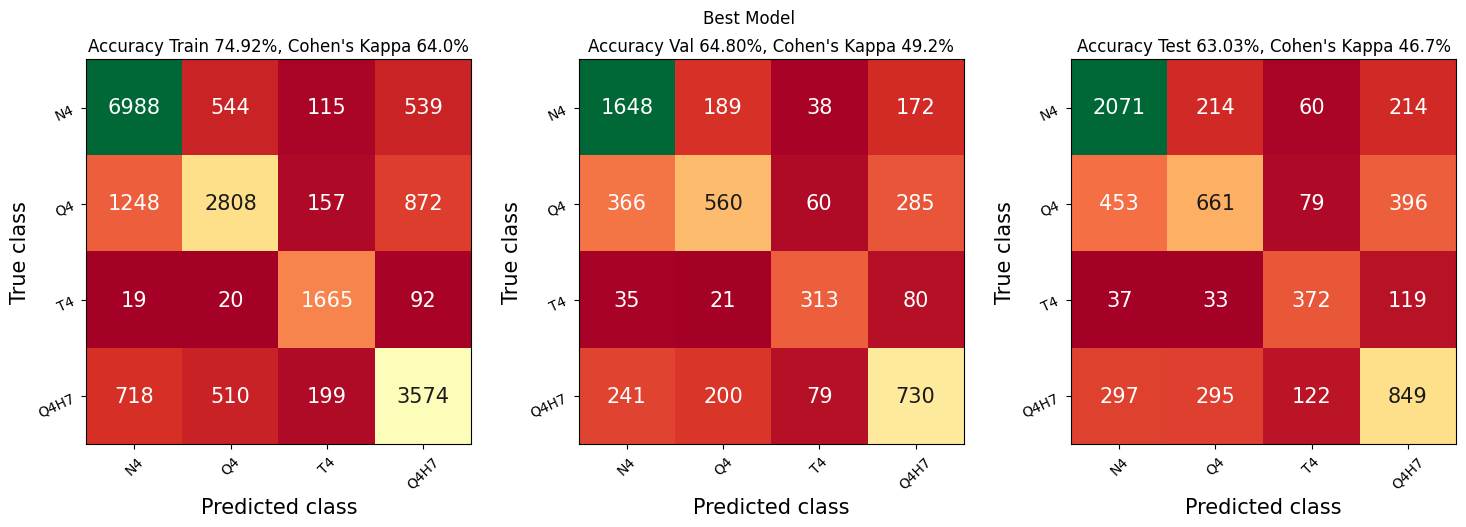

In [5]:
n_epochs = 500
trainer.summary()   
trainer.train(n_epochs)
trainer.test("best") 


In [ ]:
dataset2 = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = True,
	augment_gt = False, # "rand" or "Ca"
)
dataset2.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model2 = MixedFCTemporalModel(
    n_classes= 1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset2.length_serie,
    input_size=dataset2.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training

        
trainer2 = Trainer(
    dataset2,
    model2,
    device="cuda",
    batch_size=1500,
    criterion=None,
    is_regression=True,        
    use_class_weights=False,
    regression_bounds_y = torch.Tensor([-12,-10,-9]).to("cuda"),
    regression_bounds_y_pred = torch.Tensor([-12,-10,-9]).to("cuda"),#torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.

n_epochs = 200
trainer2.summary()   
trainer2.train(n_epochs)
trainer2.test("best") 


D:\Sebastien\PycalcActivation\src\PycalcAct\dataset.py:16: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(datapath, header=None)


Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                     30.76 │                     20.77 │
│             1             │                     24.08 │                     23.96 │
│             3             │                     27.35 │                     27.53 │
│[Epoch,  35/200, 0.35 it/s, ETA  8m] ꞏꞏꞏꞏꞏꞏꞏꞏ>   27.83 │                           │

In [ ]:
from scipy.stats import f_oneway
x, y = trainer2.dataset.test_batch(True, to_cuda=True)
y_pred = trainer2.model(torch.Tensor(x))
plt.hist(y_pred[y == 0].cpu().detach().numpy(), 50)
plt.hist(y_pred[y == 1].cpu().detach().numpy(), 50)
plt.hist(y_pred[y == 2].cpu().detach().numpy(), 50)
plt.hist(y_pred[y == 3].cpu().detach().numpy(), 50)
plt.show()

f_statistic, p_value = f_oneway(y_pred[y == 0].cpu().detach().numpy(), 
                                y_pred[y == 1].cpu().detach().numpy(), 
                                y_pred[y == 2].cpu().detach().numpy(),
                                y_pred[y == 3].cpu().detach().numpy())

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")
